In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
df = pd.read_csv("../data/passenger_master.csv")

In [6]:
df.shape

(129880, 25)

In [7]:
df.head()

,Unnamed: 0,id,Gender,Customer Type,Age,Type of Travel,Class,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,...,Inflight entertainment,On-board service,Leg room service,Baggage handling,Checkin service,Inflight service,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes,satisfaction
0,0,70172,Male,Loyal Customer,13,Personal Travel,Eco Plus,460,3,4,...,5,4,3,4,4,5,5,25,18.0,neutral or dissatisfied
1,1,5047,Male,disloyal Customer,25,Business travel,Business,235,3,2,...,1,1,5,3,1,4,1,1,6.0,neutral or dissatisfied
2,2,110028,Female,Loyal Customer,26,Business travel,Business,1142,2,2,...,5,4,3,4,4,4,5,0,0.0,satisfied
3,3,24026,Female,Loyal Customer,25,Business travel,Business,562,2,5,...,2,2,5,3,1,4,2,11,9.0,neutral or dissatisfied
4,4,119299,Male,Loyal Customer,61,Business travel,Business,214,3,3,...,3,3,4,4,3,3,3,0,0.0,satisfied


In [8]:
df.columns.tolist()

['Unnamed: 0',
 'id',
 'Gender',
 'Customer Type',
 'Age',
 'Type of Travel',
 'Class',
 'Flight Distance',
 'Inflight wifi service',
 'Departure/Arrival time convenient',
 'Ease of Online booking',
 'Gate location',
 'Food and drink',
 'Online boarding',
 'Seat comfort',
 'Inflight entertainment',
 'On-board service',
 'Leg room service',
 'Baggage handling',
 'Checkin service',
 'Inflight service',
 'Cleanliness',
 'Departure Delay in Minutes',
 'Arrival Delay in Minutes',
 'satisfaction']

In [9]:
df["Delay_Score"] = (
    (df["Arrival Delay in Minutes"]
     - df["Arrival Delay in Minutes"].min())
    /
    (
        df["Arrival Delay in Minutes"].max()
        -
        df["Arrival Delay in Minutes"].min()
    )
) * 100

In [10]:
df["Delay_Score"].describe()

count    129487.000000
mean          0.952723
std           2.428387
min           0.000000
25%           0.000000
50%           0.000000
75%           0.820707
max         100.000000
Name: Delay_Score, dtype: float64

In [11]:
service_cols = [
    'Inflight wifi service',
    'Departure/Arrival time convenient',
    'Ease of Online booking',
    'Gate location',
    'Food and drink',
    'Online boarding',
    'Seat comfort',
    'Inflight entertainment',
    'On-board service',
    'Leg room service',
    'Baggage handling',
    'Checkin service',
    'Inflight service',
    'Cleanliness'
]

In [12]:
df["Service_Quality_Score"] = df[service_cols].mean(axis=1)

In [13]:
df["Service_Quality_Score"].describe()

count    129880.000000
mean          3.241267
std           0.661728
min           1.071429
25%           2.785714
50%           3.285714
75%           3.714286
max           5.000000
Name: Service_Quality_Score, dtype: float64

In [14]:
df["Service_Dissatisfaction"] = (
    5 - df["Service_Quality_Score"]
) * 20

In [15]:
df["Service_Dissatisfaction"].describe()

count    129880.000000
mean         35.174656
std          13.234558
min           0.000000
25%          25.714286
50%          34.285714
75%          44.285714
max          78.571429
Name: Service_Dissatisfaction, dtype: float64

In [16]:
df["Travel_Difficulty"] = (
    (df["Flight Distance"]
     - df["Flight Distance"].min())
    /
    (
        df["Flight Distance"].max()
        -
        df["Flight Distance"].min()
    )
) * 100

In [24]:
df["PFI"] = (
    0.25 * df["Delay_Score"]
    +
    0.55 * df["Service_Dissatisfaction"]
    +
    0.20 * df["Travel_Difficulty"]
)


In [25]:
low = df["PFI"].quantile(0.33)
high = df["PFI"].quantile(0.66)

def friction_level(x):

    if x <= low:
        return "Low Friction"

    elif x <= high:
        return "Moderate Friction"

    else:
        return "High Friction"

df["PFI_Category"] = df["PFI"].apply(friction_level)

In [19]:
print(df["PFI"].describe())

count    129487.000000
mean         19.132790
std           6.213196
min           1.350912
25%          14.775350
50%          18.822871
75%          23.118567
max          62.683937
Name: PFI, dtype: float64


In [20]:
print(df["PFI_Category"].value_counts())

PFI_Category
Low Friction         123229
Moderate Friction      6257
High Friction           394
Name: count, dtype: int64


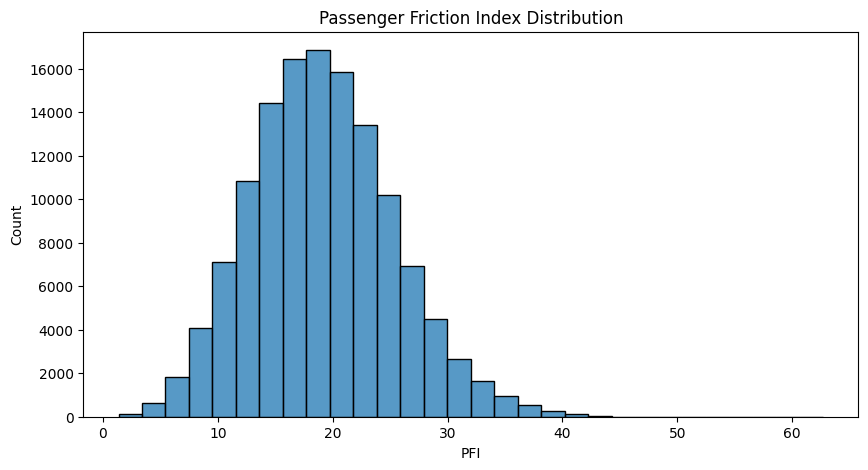

In [21]:
plt.figure(figsize=(10,5))

sns.histplot(
    df["PFI"],
    bins=30
)

plt.title("Passenger Friction Index Distribution")

plt.show()

In [22]:
df.to_csv(
    "../data/passenger_master_with_pfi.csv",
    index=False
)

In [23]:
print(df["PFI"].describe())

print(df["PFI_Category"].value_counts())

count    129487.000000
mean         19.132790
std           6.213196
min           1.350912
25%          14.775350
50%          18.822871
75%          23.118567
max          62.683937
Name: PFI, dtype: float64
PFI_Category
Low Friction         123229
Moderate Friction      6257
High Friction           394
Name: count, dtype: int64


In [26]:
print(df["PFI_Category"].value_counts())

PFI_Category
High Friction        44419
Low Friction         42731
Moderate Friction    42730
Name: count, dtype: int64
